In [1]:
import pandas as pd
import os
import pyprojroot, sys
from pyprojroot.criterion import has_file
sys.path.insert(0, str(pyprojroot.find_root(has_file("pyproject.toml"))))

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.iux001 import fetch_data, aggregation_data,merging_data1
from lib.aux001 import calc_expression
from lib.cux001 import FactorEvaluate1

./
./config/contract.toml


FileNotFoundError: [Errno 2] No such file or directory: './config/contract.toml'

In [3]:
method = 'ricso2'
instruments = 'rbb'
period = 5
task_id = '113002'
datasets = ['train','val']

In [4]:
total_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/ricso2/rbb/micro/train_data.feather
./records/ricso2/rbb/micro/val_data.feather
./records/ricso2/rbb/returns/train_returns.feather
./records/ricso2/rbb/returns/val_returns.feather


In [5]:
#market_data = total_data[['trade_time','code','open','close','high','low','volume','openint','value','value']]

In [6]:
total_data.head()

,trade_time,code,symbol,mc001_001,mc001_002,mc001_003,mc001_004,mc001_005,mc001_006,mc001_007,...,mc002_009,mc002_010,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h,nxt1_ret_15h,time_weight,equal_weight
0,2012-01-04 09:00:00,RB,rb1205,64,54,10,0.537815,0.453782,0.084034,9230,...,0.000009,0.000000,-0.000232,-0.000299,-0.000466,0.000267,0.001886,0.000109,-0.000294,-0.000333
1,2012-01-04 09:01:00,RB,rb1205,60,60,0,0.500000,0.500000,0.000000,6812,...,0.000008,0.038942,-0.000067,-0.000234,0.000484,0.001018,0.001612,0.000572,-0.000031,0.000061
2,2012-01-04 09:02:00,RB,rb1205,62,54,8,0.516667,0.450000,0.066667,3698,...,0.000005,0.358525,-0.000167,0.000551,0.000567,0.002055,0.001906,0.000699,0.000194,0.000317
3,2012-01-04 09:03:00,RB,rb1205,54,59,-5,0.450000,0.491667,-0.041667,7194,...,0.000003,0.269558,0.000718,0.000734,0.001252,0.002380,0.001595,0.000964,0.000812,0.000901
4,2012-01-04 09:04:00,RB,rb1205,50,45,5,0.416667,0.375000,0.041667,2206,...,0.000003,0.145484,0.000016,0.000534,0.001504,0.001112,0.000751,0.000517,0.000437,0.000685


In [8]:
#market_data.tail()

In [9]:
#market_data.shape

In [10]:
#total_data[['trade_time','code','tc014_1_2_5_0','oi004_1_3_1','tn008_1_3_1_2','tn008_1_3_1_3']]

In [11]:
total_data.filter(regex="^nxt1").columns.to_list()
nxt1_columns = total_data.filter(regex="^nxt1").columns.to_list()
basic_columns = [
        'close', 'high', 'low', 'open', 'volume'
        #, 'value', 'openint'
    ]

regex_pattern = r'^[^_]+_(5|10|15)_.*'
not_columns = total_data.columns[total_data.columns.str.contains(
        regex_pattern)]

factor_columns = [
        col for col in total_data.columns
        if col not in ['trade_time', 'code'] + nxt1_columns + basic_columns +
        not_columns.tolist()
    ]#[0:100]

In [14]:
#total_data
basic_columns

['close', 'high', 'low', 'open', 'volume']

In [15]:
# total_data = total_data[['trade_time', 'code'] + factor_columns + basic_columns + ["nxt1_ret_{}h".format(period)]]
total_data = total_data[['trade_time', 'code'] + factor_columns  + ["nxt1_ret_{}h".format(period)]]
total_data.head()

,trade_time,code,symbol,mc001_001,mc001_002,mc001_003,mc001_004,mc001_005,mc001_006,mc001_007,...,mc002_004,mc002_005,mc002_006,mc002_007,mc002_008,mc002_009,mc002_010,time_weight,equal_weight,nxt1_ret_5h
0,2012-01-04 09:00:00,RB,rb1205,64,54,10,0.537815,0.453782,0.084034,9230,...,-0.149019,0.617505,-0.552632,-0.000021,0.002590,0.000009,0.000000,-0.000294,-0.000333,0.000267
1,2012-01-04 09:01:00,RB,rb1205,60,60,0,0.500000,0.500000,0.000000,6812,...,-0.027797,0.628944,0.245810,-0.000005,0.002929,0.000008,0.038942,-0.000031,0.000061,0.001018
2,2012-01-04 09:02:00,RB,rb1205,62,54,8,0.516667,0.450000,0.066667,3698,...,0.188131,0.610367,-0.518919,0.000032,0.002680,0.000005,0.358525,0.000194,0.000317,0.002055
3,2012-01-04 09:03:00,RB,rb1205,54,59,-5,0.450000,0.491667,-0.041667,7194,...,0.202563,0.604250,0.778378,0.000030,0.002051,0.000003,0.269558,0.000812,0.000901,0.002380
4,2012-01-04 09:04:00,RB,rb1205,50,45,5,0.416667,0.375000,0.041667,2206,...,0.031759,0.609522,0.058394,0.000005,0.001865,0.000003,0.145484,0.000437,0.000685,0.001112


In [18]:
expression = "MSUM(5,'mc003_001')"

In [19]:
%%time
factor_data = calc_expression(expression=expression,
                              total_data=total_data.set_index('trade_time'))

CPU times: user 25.6 s, sys: 1.98 s, total: 27.6 s
Wall time: 27.6 s


In [20]:
factor_data.tail()

,trade_time,transformed,code
1024643,2025-04-30 14:56:00,-2795.0,RB
1024644,2025-04-30 14:57:00,-3112.0,RB
1024645,2025-04-30 14:58:00,-3020.0,RB
1024646,2025-04-30 14:59:00,-8023.0,RB
1024647,2025-04-30 15:00:00,-4768.0,RB


In [21]:
#factor_data.merge(total_data[['trade_time','code','nxt1_ret_15h']], on=['trade_time','code'])

In [22]:
dt = merging_data1(factor_data=factor_data,
                      returns_data=total_data,
                      period=period)

In [23]:
dt.tail(20)

,trade_time,transformed,code,nxt1_ret_5h
1024628,2025-04-30 14:41:00,14850.0,RB,-0.000550
1024629,2025-04-30 14:42:00,-8291.0,RB,-0.000191
1024630,2025-04-30 14:43:00,-9839.0,RB,-0.000466
1024631,2025-04-30 14:44:00,-7282.0,RB,-0.000081
1024632,2025-04-30 14:45:00,-11783.0,RB,0.000282
1024633,2025-04-30 14:46:00,-10045.0,RB,0.000307
1024634,2025-04-30 14:47:00,-1595.0,RB,0.000205
1024635,2025-04-30 14:48:00,-2670.0,RB,0.000318
1024636,2025-04-30 14:49:00,-2236.0,RB,0.000063
1024637,2025-04-30 14:50:00,847.0,RB,-0.000214


In [24]:
evaluate1 = FactorEvaluate1(factor_data=dt,
                                factor_name='transformed',
                                ret_name='nxt1_ret_{0}h'.format(period),
                                roll_win=15,
                                fee=0.0,
                                scale_method='roll_zscore',
                                expression=expression,
                                resampling_win=period)

In [29]:
dt.tail()

,trade_time,transformed,code,nxt1_ret_5h
1024643,2025-04-30 14:56:00,-2795.0,RB,0.007984
1024644,2025-04-30 14:57:00,-3112.0,RB,0.007496
1024645,2025-04-30 14:58:00,-3020.0,RB,0.006050
1024646,2025-04-30 14:59:00,-8023.0,RB,0.006199
1024647,2025-04-30 15:00:00,-4768.0,RB,-0.000215


In [25]:
stats_dt = evaluate1.run()

In [26]:
stats_dt

{'total_ret': 84.48507537246995,
 'avg_ret': 2.1088316307675184e-05,
 'max_dd': -0.10611314287679519,
 'calmar': 3.7335619392950257,
 'sharpe1': 0.02733065521088079,
 'sharpe2': 2.996386992909577,
 'turnover': 0.4543334710608427,
 'win_rate': 0.518187554039212,
 'profit_ratio': 1.117230764197331,
 'total_ic': -0.021307745431463982,
 'ic_mean': -0.1312539965959514,
 'ic_std': 0.2500268590533011,
 'ic_ir': -0.5249595867137238,
 'factor_autocorr': 0.13202751662796317,
 'ret_autocorr': -0.031448879878869955,
 'factor_coverage': 1.0,
 'factor_mean': -85.3911621059519,
 'factor_std': 8896.725466616375,
 'factor_skew': 0.08389364882052089,
 'factor_kurtosis': 13.14517174522552}

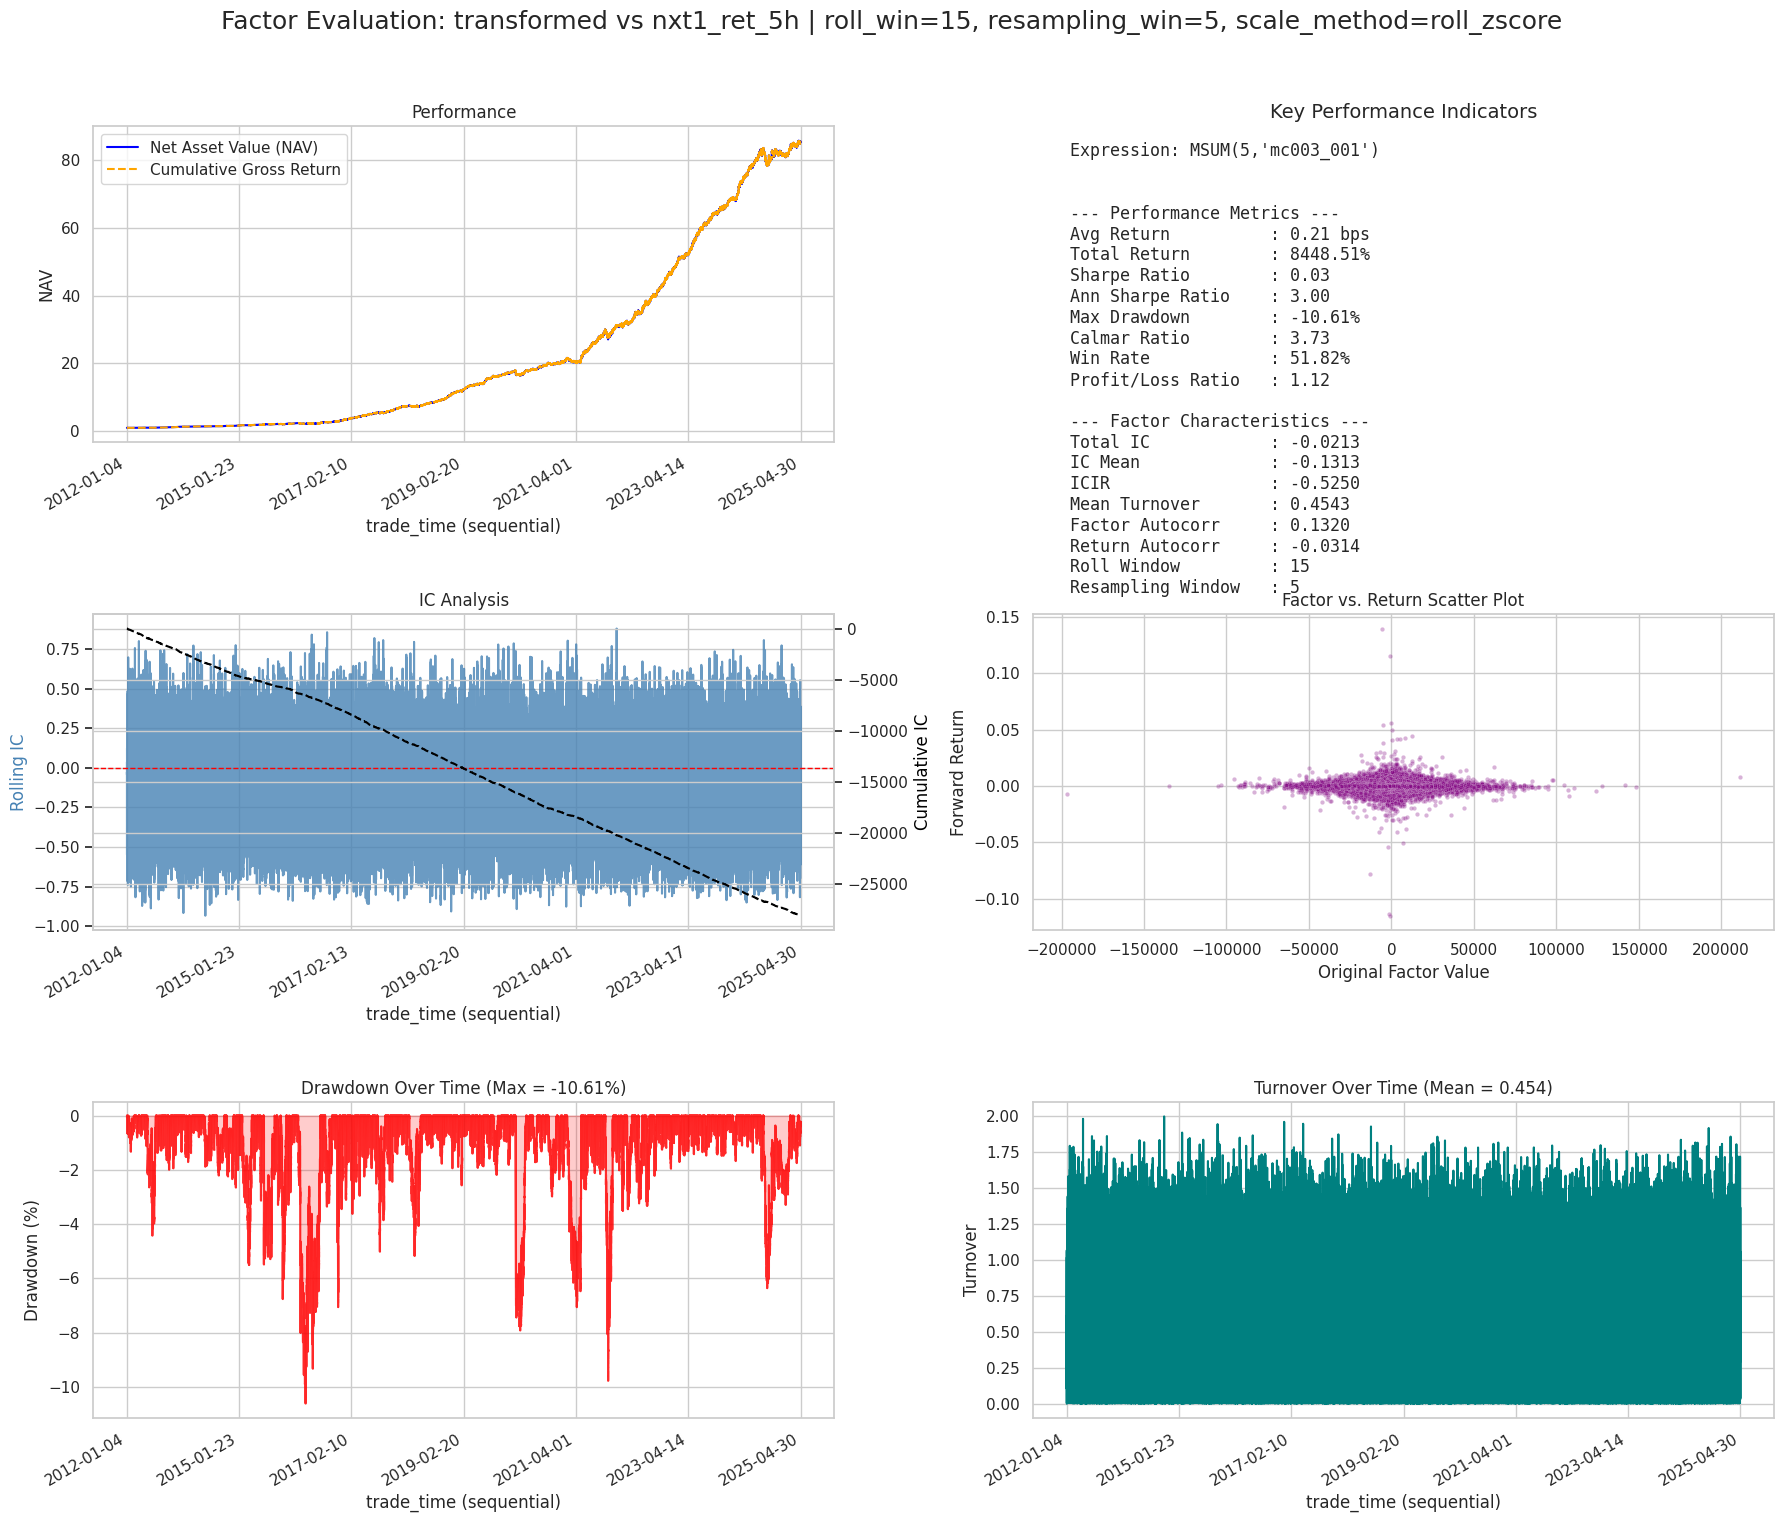

In [27]:
evaluate1.plot_results()

In [18]:
evaluate1.save_results(base_output_dir='./')

Saving results to: ./20251102_074903
Performance summary saved to: ./20251102_074903/performance_summary.txt
Saving time series data as separate files...
 -> Saved ./20251102_074903/nav.csv
 -> Saved ./20251102_074903/ic.csv
 -> Saved ./20251102_074903/turnover.csv
Evaluation plot saved to: ./20251102_074903/evaluation_plot.png
Evaluation plot also saved to: ./plot/20251102_074903.png


In [49]:
evaluate1.resample_data.loc['2021-11-25 21:00:00':'2024-08-22 14:55:00']['net_ret'].cumsum()

trade_time
2021-11-25 21:00:00   -0.001828
2021-11-25 21:05:00   -0.001815
2021-11-25 21:10:00   -0.002119
2021-11-25 21:15:00   -0.001526
2021-11-25 21:20:00   -0.000474
                         ...   
2024-08-22 00:10:00    1.002449
2024-08-22 00:15:00    1.002430
2024-08-22 00:20:00    1.002437
2024-08-22 00:25:00    1.002593
2024-08-22 00:30:00    1.002703
Name: net_ret, Length: 55029, dtype: float64

In [23]:
delta_days = (evaluate1.resample_data.index[-1] - evaluate1.resample_data.index[0]).days

In [26]:
years = delta_days / 365

In [29]:
ann_ret = (1 + evaluate1.resample_data['nav'].iloc[-1] - 1) ** (1 / years) - 1 #
ann_ret

0.26715944265063696

In [30]:
max_dd = (evaluate1.resample_data['nav'] / evaluate1.resample_data['nav'].cummax() -
                  1).min()
max_dd

-0.1615508011172847

In [31]:
ann_ret / abs(max_dd)

1.6537178448077219

In [32]:
evaluate1.resample_data

,transformed,nxt1_ret_5h,f_scaled,ic,cumsum_ic,pos,gross_ret,turnover,net_ret,nav
trade_time,,,,,,,,,,
2011-01-04 09:20:00,0.126883,0.000394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04 09:25:00,0.577287,-0.000666,-0.469340,NaN,NaN,-0.469340,0.000313,NaN,NaN,NaN
2011-01-04 09:30:00,1.095944,0.000358,-0.511118,NaN,NaN,-0.511118,-0.000183,0.041778,-0.000183,0.999817
2011-01-04 09:35:00,1.799741,-0.000109,-0.446699,NaN,NaN,-0.446699,0.000049,0.064419,0.000049,0.999865
2011-01-04 09:40:00,2.697456,0.000467,-0.270207,0.288929,0.288929,-0.270207,-0.000126,0.176491,-0.000126,0.999739
...,...,...,...,...,...,...,...,...,...,...
2024-02-21 09:30:00,7.091149,0.000226,-0.482457,-0.446571,-51419.700357,-0.482457,-0.000109,0.931870,-0.000109,22.429100
2024-02-21 09:35:00,7.170121,0.000865,0.470528,-0.450446,-51420.150803,0.470528,0.000407,0.952985,0.000407,22.438226
2024-02-21 09:40:00,7.555766,0.000617,-0.506395,-0.376140,-51420.526942,-0.506395,-0.000313,0.976923,-0.000313,22.431211


In [34]:
evaluate1.resample_data['ic'] 

trade_time
2011-01-04 09:20:00         NaN
2011-01-04 09:25:00         NaN
2011-01-04 09:30:00         NaN
2011-01-04 09:35:00         NaN
2011-01-04 09:40:00    0.288929
                         ...   
2024-02-21 09:30:00   -0.446571
2024-02-21 09:35:00   -0.450446
2024-02-21 09:40:00   -0.376140
2024-02-21 09:45:00    0.205909
2024-02-21 09:50:00    0.217221
Name: ic, Length: 204556, dtype: float64